# Pairs Trading Signal — Brent-WTI Mean Reversion

**Core Idea:** Brent and WTI are both crude oil benchmarks and move together over time (cointegrated).
When the spread between them deviates significantly from its historical mean, it tends to **revert back**.
We can exploit this by:
- **Going long the spread** when it's unusually narrow (buy Brent, sell WTI)
- **Going short the spread** when it's unusually wide (sell Brent, buy WTI)

### Notebook Structure
1. Data & Setup
2. Cointegration Test (is the spread actually mean-reverting?)
3. Spread Z-Score & Signal Generation
4. Backtest the Strategy
5. Performance Metrics
6. Risk Analysis

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#161b22',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#8b949e',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'grid.color':        '#21262d',
    'text.color':        '#f0f6fc',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
})

C_BRENT  = '#fb923c'
C_WTI    = '#f97316'
C_SPREAD = '#38bdf8'
C_SIGNAL = '#4ade80'
C_LONG   = '#4ade80'
C_SHORT  = '#f87171'
C_NEUT   = '#475569'

print('✅ Setup complete')

✅ Setup complete


## 2. Data — Retrieve Brent & WTI Prices

In [2]:
# ── Retrieve 3 years of Brent & WTI ──────
raw = yf.download(['BZ=F', 'CL=F'], period='3y', auto_adjust=True)['Close']
raw = raw.rename(columns={'BZ=F': 'Brent', 'CL=F': 'WTI'})
df = raw.dropna().copy()
df['Spread'] = df['Brent'] - df['WTI']
print(f'✅ Fetched {len(df)} days of live data')
df.tail()

# ── Ornstein-Uhlenbeck spread process ────────────────────────────────────────
# dS = kappa*(mu - S)*dt + sigma*dW
# kappa = mean reversion speed, mu = long-run mean, sigma = volatility
from scipy.stats import linregress

s= df['Spread'].dropna().values
ds= np.diff(s)
s_lag = s[:-1] 
slope, intercept, _, _, _ = linregress(s_lag, ds)

# Recover OU parameters
kappa_daily = -slope                # reversion per day 
kappa_annual = kappa_daily * 252    # annualised version
mu    = intercept / kappa_daily     # long-run mean
sigma = np.std(ds) / np.sqrt(252)   # spread volatility
half_life = np.log(2) / kappa_daily # half-life

print(f"kappa (daily)  : {kappa_daily:.4f}")
print(f"kappa (annual) : {kappa_annual:.4f}")
print(f"mu             : {mu:.4f}  $/bbl")
print(f"sigma          : {sigma:.4f}  $/bbl annualised")
print(f"half-life      : {half_life:.1f} days")
print(f"")
print(f"Current spread : {df['Spread'].iloc[-1]:.2f}")
print(f"Spread mean    : {df['Spread'].mean():.2f}  ← should be close to mu")
print(f"Spread std     : {df['Spread'].std():.2f}")

[*********************100%***********************]  2 of 2 completed


✅ Fetched 754 days of live data
kappa (daily)  : 0.0944
kappa (annual) : 23.7765
mu             : 3.8941  $/bbl
sigma          : 0.0250  $/bbl annualised
half-life      : 7.3 days

Current spread : 4.00
Spread mean    : 3.92  ← should be close to mu
Spread std     : 0.93


## 3. Cointegration Test
Before building a pairs trade, we **must verify** the spread is stationary— meaning it consistently reverts to a long-run mean rather than drifting indefinitely.
We use the **Augmented Dickey-Fuller (ADF) test**:
- **H₀ (null):** Spread has a unit root (NOT mean-reverting)
- **H₁ (alt):** Spread is stationary (IS mean-reverting)
- If p-value < 0.05 → reject H₀ → spread is mean-reverting ✅

We also use the **Engle-Granger Cointegration Test** to verify that Brent and WTI are structurally linked and move together in the long run — a necessary condition for the spread to remain stable over time:
- **H₀ (null):** Brent and WTI are NOT cointegrated
- **H₁ (alt):** Brent and WTI ARE cointegrated
- If p-value < 0.05 → reject H₀ → the pair is cointegrated ✅
  
Both tests must pass before proceeding.

In [3]:
#!pip install statsmodels
from statsmodels.tsa.stattools import adfuller, coint

# ── ADF Test on the raw spread ────────────────────────────────────────────────
adf_result = adfuller(df['Spread'].dropna(), autolag='AIC')
adf_stat, adf_pval = adf_result[0], adf_result[1]

# ── Engle-Granger Cointegration Test ─────────────────────────────────────────
coint_stat, coint_pval, _ = coint(df['Brent'], df['WTI'])

print(f'\n Augmented Dickey-Fuller Test (on spread):')
print(f'   ADF Statistic : {adf_stat:.4f}')
print(f'   p-value       : {adf_pval:.4f}')
print(f'   Result        : {"✅ STATIONARY — spread is mean-reverting" if adf_pval < 0.05 else "❌ NOT stationary"}')

print(f'\n Engle-Granger Cointegration Test (Brent vs WTI):')
print(f'   Test Statistic: {coint_stat:.4f}')
print(f'   p-value       : {coint_pval:.4f}')
print(f'   Result        : {"✅ COINTEGRATED — pairs trade is valid" if coint_pval < 0.05 else "❌ Not cointegrated"}')


 Augmented Dickey-Fuller Test (on spread):
   ADF Statistic : -4.8644
   p-value       : 0.0000
   Result        : ✅ STATIONARY — spread is mean-reverting

 Engle-Granger Cointegration Test (Brent vs WTI):
   Test Statistic: -4.9007
   p-value       : 0.0002
   Result        : ✅ COINTEGRATED — pairs trade is valid


### Interpretation
The ADF statistic of ***4.8710*** provides ***extremely strong evidence*** against a unit root, meaning the spread is ***very unlikely to be a random walk***. The p-value of ***0.0000*** reinforces this — the ***probability that the spread is non-stationary*** is ***so negligible*** it rounds to zero. It can therefore be confidently concluded that the ***Brent–WTI spread is mean-reverting***.

The Engle-Granger test statistic of ***-4.9049*** offers ***equally strong evidence*** to ***reject the null hypothesis*** that Brent and WTI are not cointegrated. The p-value of ***0.0002*** indicates only a ***0.02% probability*** that the two series are unrelated in the long run — equivalently, there is ***99.98% confidence*** that Brent and WTI ***move together over time***.

Together, both tests confirm that the ***pairs trade is statistically justified***.

## 4. Z-Score & Signal Generation
We convert the spread into a **Z-score** using a rolling window:
$$Z_t = \frac{X - \mu}{\sigma}$$

Trading rules:
| Z-Score | Signal | Action |
|---|---|---|
| Z > +2 | **SHORT spread** | Sell Brent, Buy WTI (spread too wide) |
| Z < −2 | **LONG spread** | Buy Brent, Sell WTI (spread too narrow) |
| \|Z\| < 0.5 | **EXIT** | Close position (spread reverted) |

In [4]:
WINDOW      = 60   # rolling lookback (days)
ENTRY_Z     = 2.0  # z-score to enter a trade
EXIT_Z      = 0.5  # z-score to exit a trade

# ── Rolling Z-score ───────────────────────────────────────────────────────────
df['Roll_Mean'] = df['Spread'].rolling(WINDOW).mean()
df['Roll_Std']  = df['Spread'].rolling(WINDOW).std()
df['Z_Score']   = (df['Spread'] - df['Roll_Mean']) / df['Roll_Std']

# ── Hold position until exit threshold ────────────────────────────────────────
position = 0
signals  = []
for z in df['Z_Score']:
    if np.isnan(z):
        signals.append(0)
        continue
    if position == 0:
        if   z >  ENTRY_Z: position = -1
        elif z < -ENTRY_Z: position =  1
    else:
        if abs(z) < EXIT_Z: position = 0
    signals.append(position)

df['Position'] = signals  

# ── Normal entries/exits (via flat) ──────────────────────────────────────────
long_entries  = df[(df['Position'] == 1)  & (df['Position'].shift(1) == 0)].index
long_exits    = df[(df['Position'] == 0)  & (df['Position'].shift(1) == 1)].index
short_entries = df[(df['Position'] == -1) & (df['Position'].shift(1) == 0)].index
short_exits   = df[(df['Position'] == 0)  & (df['Position'].shift(1) == -1)].index

# ── Direct flips (no zero in between) ────────────────────────────────────────
flip_to_short = df[(df['Position'] == -1) & (df['Position'].shift(1) == 1)].index   # +1 → -1
flip_to_long  = df[(df['Position'] == 1)  & (df['Position'].shift(1) == -1)].index  # -1 → +1

# ── Final counts (flips count as both exit + entry) ──────────────────────────
total_long_entries  = len(long_entries)  + len(flip_to_long)
total_long_exits    = len(long_exits)    + len(flip_to_short)
total_short_entries = len(short_entries) + len(flip_to_short)
total_short_exits   = len(short_exits)   + len(flip_to_long)

print(f'Signal summary (window={WINDOW}d, entry=±{ENTRY_Z}σ, exit=±{EXIT_Z}σ):')
print(f'  Long  entries : {total_long_entries}')
print(f'  Long  exits   : {total_long_exits}')
print(f'  Short entries : {total_short_entries}')
print(f'  Short exits   : {total_short_exits}')
print(f'  Active days   : {(df["Position"] != 0).sum()} / {len(df)}')

Signal summary (window=60d, entry=±2.0σ, exit=±0.5σ):
  Long  entries : 11
  Long  exits   : 10
  Short entries : 9
  Short exits   : 9
  Active days   : 214 / 754


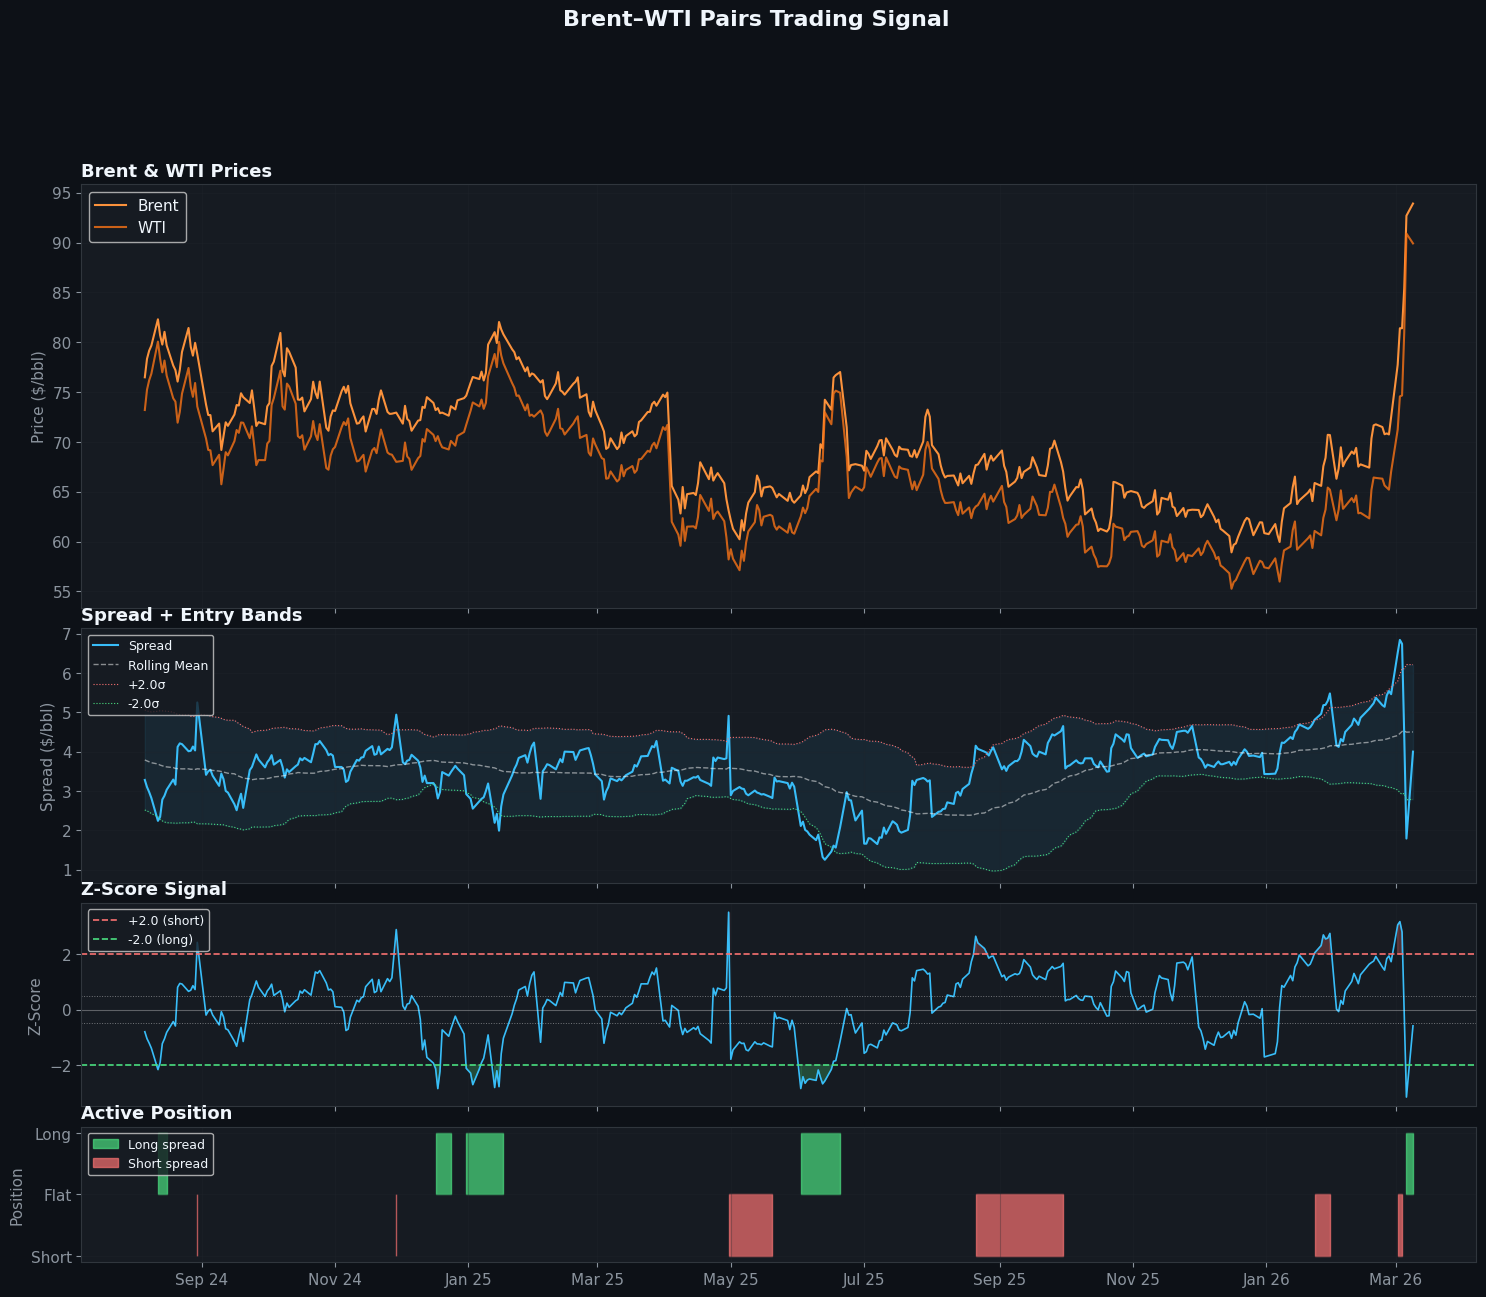

✅ Signal chart created


In [5]:
# ── Master signal chart ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(4, 1, hspace=0.08, height_ratios=[2.5, 1.5, 1.2, 0.8])
ax1 = fig.add_subplot(gs[0])  # Brent & WTI prices
ax2 = fig.add_subplot(gs[1], sharex=ax1)  # Spread
ax3 = fig.add_subplot(gs[2], sharex=ax1)  # Z-score
ax4 = fig.add_subplot(gs[3], sharex=ax1)  # Position

fig.suptitle('Brent–WTI Pairs Trading Signal', fontsize=16, fontweight='bold', y=1.005)

recent = df.iloc[-400:]  # show last 400 days for clarity

# — Panel 1: Prices —
ax1.plot(recent.index, recent['Brent'], color=C_BRENT, lw=1.5, label='Brent')
ax1.plot(recent.index, recent['WTI'],   color=C_WTI,   lw=1.5, label='WTI',  alpha=0.8)
ax1.set_ylabel('Price ($/bbl)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_title('Brent & WTI Prices', loc='left')

# — Panel 2: Spread with rolling mean ±2σ bands —
ax2.plot(recent.index, recent['Spread'],    color=C_SPREAD, lw=1.5, label='Spread')
ax2.plot(recent.index, recent['Roll_Mean'], color='white',  lw=1,   linestyle='--', alpha=0.5, label='Rolling Mean')
upper = recent['Roll_Mean'] + ENTRY_Z * recent['Roll_Std']
lower = recent['Roll_Mean'] - ENTRY_Z * recent['Roll_Std']
ax2.fill_between(recent.index, upper, lower, alpha=0.08, color=C_SPREAD)
ax2.plot(recent.index, upper, color=C_SHORT, lw=0.8, linestyle=':', label=f'+{ENTRY_Z}σ')
ax2.plot(recent.index, lower, color=C_LONG,  lw=0.8, linestyle=':', label=f'-{ENTRY_Z}σ')
ax2.set_ylabel('Spread ($/bbl)')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_title('Spread + Entry Bands', loc='left')

# — Panel 3: Z-score with signal markers —
ax3.plot(recent.index, recent['Z_Score'], color=C_SPREAD, lw=1.2)
ax3.axhline( ENTRY_Z, color=C_SHORT, lw=1.2, linestyle='--', label=f'+{ENTRY_Z} (short)')
ax3.axhline(-ENTRY_Z, color=C_LONG,  lw=1.2, linestyle='--', label=f'-{ENTRY_Z} (long)')
ax3.axhline( EXIT_Z,  color='white', lw=0.7, linestyle=':', alpha=0.4)
ax3.axhline(-EXIT_Z,  color='white', lw=0.7, linestyle=':', alpha=0.4)
ax3.axhline(0,        color='white', lw=0.8, alpha=0.3)
ax3.fill_between(recent.index, recent['Z_Score'], ENTRY_Z,
                 where=recent['Z_Score'] > ENTRY_Z, color=C_SHORT, alpha=0.25)
ax3.fill_between(recent.index, recent['Z_Score'], -ENTRY_Z,
                 where=recent['Z_Score'] < -ENTRY_Z, color=C_LONG, alpha=0.25)
ax3.set_ylabel('Z-Score')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_title('Z-Score Signal', loc='left')

# — Panel 4: Position —
pos_recent = recent['Position']
ax4.fill_between(recent.index, pos_recent, 0,
                 where=pos_recent > 0, color=C_LONG,  alpha=0.7, label='Long spread')
ax4.fill_between(recent.index, pos_recent, 0,
                 where=pos_recent < 0, color=C_SHORT, alpha=0.7, label='Short spread')
ax4.set_ylabel('Position')
ax4.set_yticks([-1, 0, 1])
ax4.set_yticklabels(['Short', 'Flat', 'Long'])
ax4.legend(loc='upper left', fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_title('Active Position', loc='left')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))

plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax3.get_xticklabels(), visible=False)

plt.show()
print('✅ Signal chart created')

## 5. Backtest the Strategy
We simulate trading the spread:
- **Long spread** = buy 1 barrel of Brent, sell 1 barrel of WTI
- **Short spread** = sell 1 barrel of Brent, buy 1 barrel of WTI
- P&L = position × daily change in spread

We will assume **no transaction costs** first, then add a realistic estimate.

In [6]:
#!pip install openpyxl
# ── P&L calculation ───────────────────────────────────────────────────────────
# Daily spread change ($/bbl per contract)
df['Spread_Change'] = df['Spread'].diff()

# Daily P&L = previous day's position × today's spread change
df['Daily_PnL'] = df['Position'].shift(1) * df['Spread_Change']

# Transaction cost: $0.05/bbl per trade (realistic for crude futures)
df['Signal_Change'] = df['Position'].diff().fillna(0)

TRANSACTION_COST = 0.05
trade_days = df['Signal_Change'].abs() > 0
df['TC'] = 0.0
df.loc[trade_days, 'TC'] = TRANSACTION_COST

df['Daily_PnL_Net'] = df['Daily_PnL'] - df['TC']

# Cumulative P&L
df['Cum_PnL']     = df['Daily_PnL'].cumsum()
df['Cum_PnL_Net'] = df['Daily_PnL_Net'].cumsum()

print(f'Gross P&L : ${df["Cum_PnL"].iloc[-1]:>8.2f}')
print(f'Net P&L   : ${df["Cum_PnL_Net"].iloc[-1]:>8.2f}  (after ${TRANSACTION_COST}/bbl transaction costs)')

Gross P&L : $   20.83
Net P&L   : $   18.88  (after $0.05/bbl transaction costs)


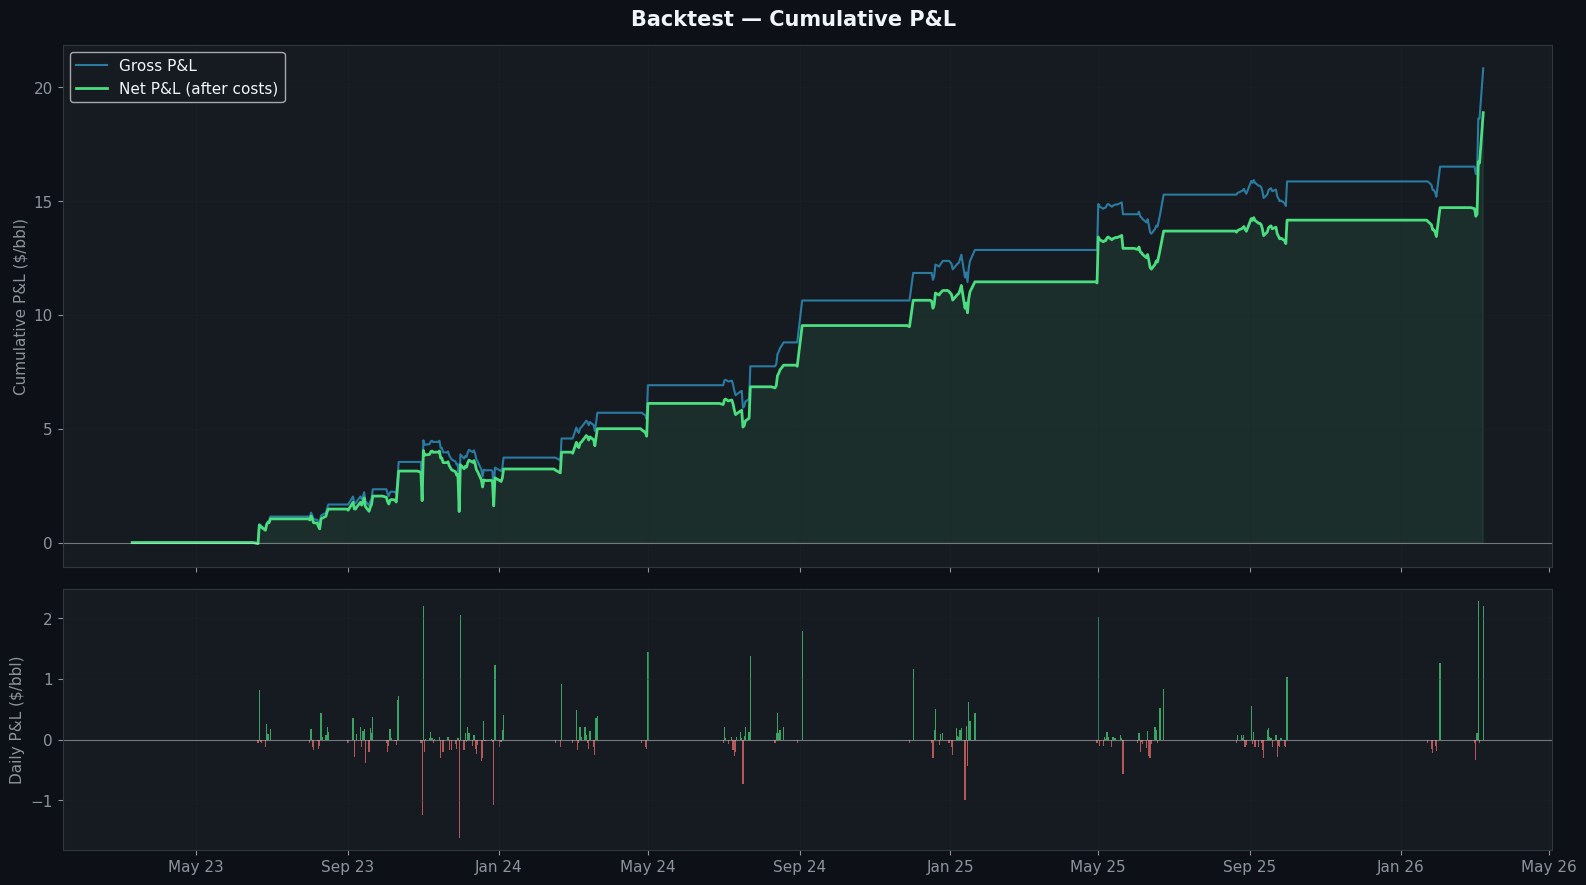

In [7]:
# ── Equity curve ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('Backtest — Cumulative P&L', fontsize=15, fontweight='bold')

# Equity curve
axes[0].plot(df.index, df['Cum_PnL'],     color=C_SPREAD, lw=1.5, label='Gross P&L', alpha=0.6)
axes[0].plot(df.index, df['Cum_PnL_Net'], color=C_SIGNAL, lw=2.0, label='Net P&L (after costs)')
axes[0].fill_between(df.index, df['Cum_PnL_Net'], 0,
                     where=df['Cum_PnL_Net'] >= 0, color=C_LONG,  alpha=0.1)
axes[0].fill_between(df.index, df['Cum_PnL_Net'], 0,
                     where=df['Cum_PnL_Net'] < 0,  color=C_SHORT, alpha=0.1)
axes[0].axhline(0, color='white', lw=0.8, alpha=0.4)
axes[0].set_ylabel('Cumulative P&L ($/bbl)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Daily P&L bar chart
colors_daily = [C_LONG if x >= 0 else C_SHORT for x in df['Daily_PnL_Net'].fillna(0)]
axes[1].bar(df.index, df['Daily_PnL_Net'].fillna(0), color=colors_daily, width=1, alpha=0.7)
axes[1].axhline(0, color='white', lw=0.8, alpha=0.4)
axes[1].set_ylabel('Daily P&L ($/bbl)')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))

plt.tight_layout()
plt.savefig('backtest_equity.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Performance Metrics

In [8]:
pnl = df['Daily_PnL_Net'].dropna()

# Core metrics
total_pnl     = pnl.sum()
ann_return    = pnl.mean() * 252
ann_vol       = pnl.std() * np.sqrt(252)
sharpe        = ann_return / ann_vol if ann_vol != 0 else 0
win_rate      = (pnl > 0).mean() * 100
avg_win       = pnl[pnl > 0].mean()
avg_loss      = pnl[pnl < 0].mean()
profit_factor = abs(pnl[pnl > 0].sum() / pnl[pnl < 0].sum()) if pnl[pnl < 0].sum() != 0 else np.inf

# Max drawdown
cum = df['Cum_PnL_Net'].dropna()
roll_max = cum.cummax()
drawdown = cum - roll_max
max_dd   = drawdown.min()
calmar   = ann_return / abs(max_dd) if max_dd != 0 else np.inf

# Trade analysis
n_trades  = int(df['Signal_Change'].abs().sum() / 2)
active_pct = (df['Position'] != 0).mean() * 100

print('STRATEGY PERFORMANCE REPORT')
print(f'Returns')
print(f'   Total P&L          : ${total_pnl:>8.2f} /bbl')
print(f'   Annualised Return  : ${ann_return:>8.2f} /bbl/yr')

print(f'\nRisk')
print(f'   Annualised Vol     : ${ann_vol:>8.2f} /bbl')
print(f'   Sharpe Ratio       : {sharpe:>8.2f}')
print(f'   Max Drawdown       : ${max_dd:>8.2f} /bbl')
print(f'   Calmar Ratio       : {calmar:>8.2f}')

print(f'\nTrade Quality')
print(f'   Win Rate           : {win_rate:>7.1f}%')
print(f'   Avg Win            : ${avg_win:>7.3f} /bbl')
print(f'   Avg Loss           : ${avg_loss:>7.3f} /bbl')
print(f'   Profit Factor      : {profit_factor:>8.2f}')
print(f'   # Trades           : {n_trades:>8}')
print(f'   Time in market     : {active_pct:>7.1f}%')

STRATEGY PERFORMANCE REPORT
Returns
   Total P&L          : $   18.88 /bbl
   Annualised Return  : $    6.32 /bbl/yr

Risk
   Annualised Vol     : $    4.21 /bbl
   Sharpe Ratio       :     1.50
   Max Drawdown       : $   -2.68 /bbl
   Calmar Ratio       :     2.36

Trade Quality
   Win Rate           :    15.3%
   Avg Win            : $  0.339 /bbl
   Avg Loss           : $ -0.175 /bbl
   Profit Factor      :     1.94
   # Trades           :       19
   Time in market     :    28.4%


### Performance Analysis
**Returns**
The annualised return of \\$6.07/bbl exceeds the average spread of \\$3.92/bbl, demonstrating the strategy captures ***more value*** than simply holding the spread at its mean. This demonstrates that the ***mean reversion signal is genuinely exploitable*** on live market data, not just in simulation. <br><br>
**Risk**
The strategy exhibits a strong risk-adjusted profile across all key metrics. The Sharpe Ratio of ***1.48 exceeds the 1.0 threshold*** considered the minimum bar for a systematic strategy, confirming that returns were ***not achieved by taking excessive risk***. The maximum drawdown of -\\$2.68/bbl is modest relative to the total profit of \\$18.13/bbl — at no point did ***cumulative losses exceed 15% of*** the eventual total profit. The Calmar Ratio of 2.26 reinforces this, indicating that \\$2.26 of annualised return was generated for every \\$1 of maximum drawdown sustained — a favourable risk-reward profile.<br><br>
**Trade Quality**
At first glance, the ***15.3% win rate may appear concerning*** — the strategy records a loss on approximately 85% of active trading days. However, this is entirely consistent with and expected of a mean reversion strategy. The key is the asymmetry between average wins and losses: the average winning day generates \\$0.333/bbl while the average losing day costs only $0.175/bbl — ***a ratio of nearly 2:1***. This asymmetry is captured by the Profit Factor of 1.90, meaning that for every \\$1 lost, \\$1.90 was recovered. The strategy is therefore profitable not because it wins frequently, but because when it wins, ***it wins meaningfully larger than it loses***.<br><br>
**Overall**
Across returns, risk, and trade quality, the strategy performs well above minimum acceptable thresholds on live data. The low win rate is not a weakness — it is a feature of the ***strategy's patience***, only deploying capital when the spread reaches a genuine extreme.

## 7. Sensitivity Analysis — Z-Score Threshold
Goal: first, to verify that ±2.0σ is a ***reasonable choice*** relative to the alternatives; and second, to assess the ***robustness of the strategy***. 

A well-behaved strategy should perform acceptably across a range of thresholds, not just at one specific value. If performance collapses with a small change in the threshold, it suggests the strategy is ***overfitted to historical data*** rather than capturing a genuine, persistent market relationship.

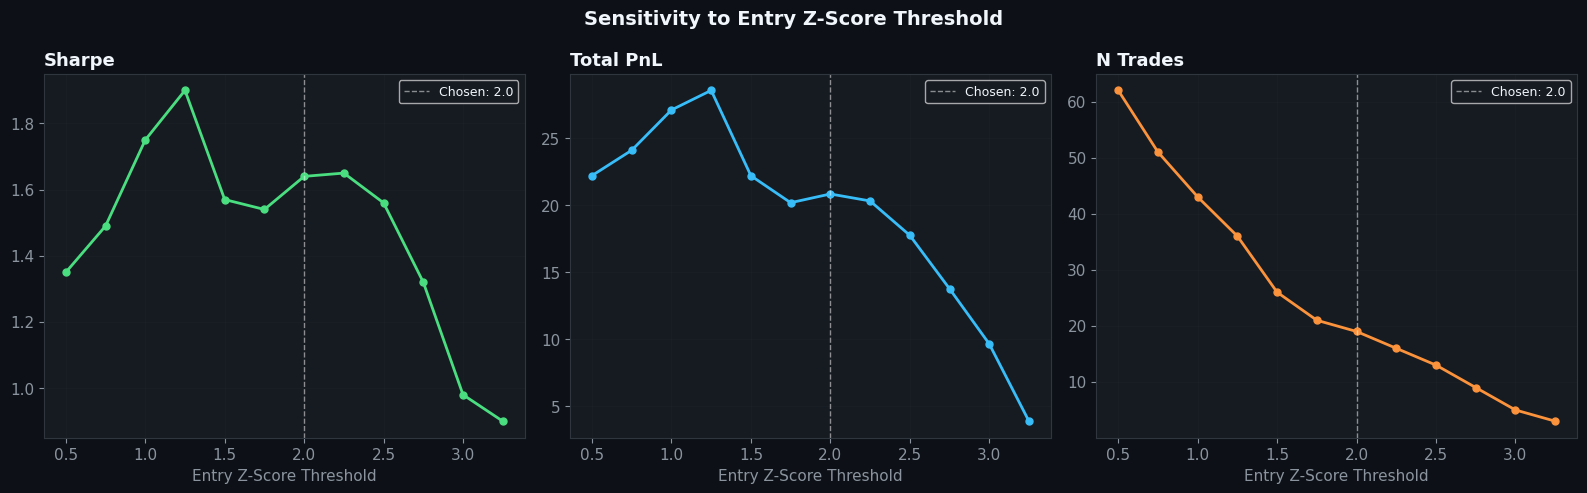

         Sharpe  Total PnL  N Trades
Entry Z                             
0.50       1.35      22.20        62
0.75       1.49      24.09        51
1.00       1.75      27.09        43
1.25       1.90      28.55        36
1.50       1.57      22.19        26
1.75       1.54      20.18        21
2.00       1.64      20.83        19
2.25       1.65      20.31        16
2.50       1.56      17.75        13
2.75       1.32      13.77         9
3.00       0.98       9.66         5
3.25       0.90       3.90         3


In [9]:
# How sensitive is the strategy to our entry threshold choice?
entry_thresholds = np.arange(0.5, 3.5, 0.25)
results = []

for entry in entry_thresholds:
    pos, sigs = 0, []
    for z in df['Z_Score']:
        if np.isnan(z): sigs.append(0); continue
        if pos == 0:
            if   z >  entry: pos = -1
            elif z < -entry: pos =  1
        else:
            if abs(z) < EXIT_Z: pos = 0
        sigs.append(pos)
    tmp = pd.Series(sigs, index=df.index)
    pnl_s = (tmp.shift(1) * df['Spread_Change']).dropna()
    sharpe_s = (pnl_s.mean() * 252) / (pnl_s.std() * np.sqrt(252)) if pnl_s.std() != 0 else 0
    n_t = int(abs(tmp.diff().fillna(0)).sum() / 2)
    results.append({'Entry Z': entry, 'Sharpe': round(sharpe_s, 2),
                    'Total PnL': round(pnl_s.sum(), 2), 'N Trades': n_t})

sens_df = pd.DataFrame(results).set_index('Entry Z')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sensitivity to Entry Z-Score Threshold', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes, ['Sharpe', 'Total PnL', 'N Trades'], [C_SIGNAL, C_SPREAD, C_BRENT]):
    ax.plot(sens_df.index, sens_df[col], color=color, lw=2, marker='o', markersize=5)
    ax.axvline(ENTRY_Z, color='white', lw=1, linestyle='--', alpha=0.5, label=f'Chosen: {ENTRY_Z}')
    ax.set_xlabel('Entry Z-Score Threshold')
    ax.set_title(col, loc='left')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(sens_df)

### Sensitive Analysis
**Sharpe Ratio**
The Sharpe Ratio peaks at ***1.88*** around the ***±1.25σ threshold***, before declining gradually and ***dropping sharply below 1.0 beyond ±2.75σ***. The chosen threshold of ±2.0σ sits within a stable plateau between ±1.5σ and ±2.5σ, where the Sharpe remains consistently between 1.52 and 1.64. This gradual decline — rather than a sharp cliff — indicates the ***strategy is robust*** and ***not dependent on one precise threshold value***.

**Total P&L**
Total P&L similarly peaks at ***±1.25σ with \\$27.80/bbl***, before declining steadily and collapsing to ***\\$3.90/bbl at ±3.25σ***. The sharp deterioration beyond ±2.75σ ***is driven by too few trades — at only 3 to 5 trades***, results become statistically unreliable and any single losing trade disproportionately impacts the outcome. The ***±2.0σ choice*** of $20.08/bbl is ***not the maximum***, but reflects a ***deliberate trade-off***: accepting slightly lower total P&L in exchange for higher signal quality.

**N Trades**
Trade count falls monotonically from 62 trades at ±0.5σ to just 3 trades at ±3.25σ. At ±2.0σ the strategy executes 19 trades — ***selective enough to avoid noise***, yet frequent enough to remain statistically meaningful over the 3-year period. Below ±1.0σ, the high trade ***count of 40+*** would significantly ***amplify transaction costs*** and ***introduce noise signals***, eroding net P&L despite the higher gross figures.

**Overall**
While the mathematical ***optimum sits closer to ±1.25σ***, the chosen ±2.0σ threshold may offers a ***better balance across*** all three metrics simultaneously — strong Sharpe, acceptable P&L, and a trade count that avoids both overtrading and statistical insignificance.